## Error de reconstrucción por clase

Usando fashion como dataset
Encontrados 9 pares de modelos.


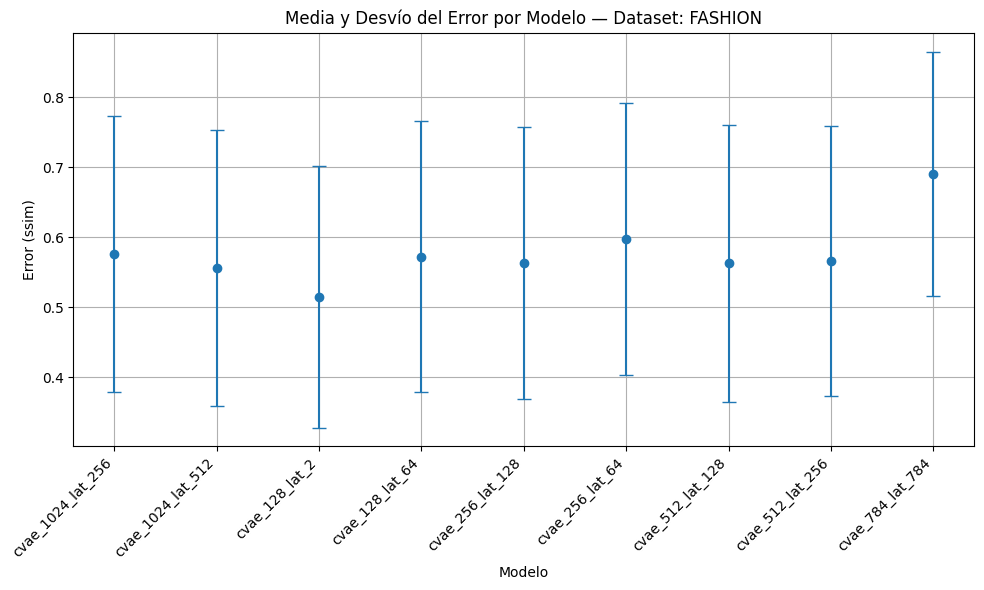

In [3]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import load
from project.metrics.metrics import Metrics 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
dataset = "fashion"

data = load.data(dataset=dataset)

models = load.all_models(dataset=dataset)

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
metric = "ssim"
idx = 0
n_pictures = 1000
errores = []  # lista de filas, cada fila = un modelo

for m in models:

    errores_modelo = []   # fila de errores para este modelo

    for idx in range(n_pictures):
        x = x_test[idx : idx + 1]  # (1, 28, 28)
        y = y_test[idx : idx + 1]  # (1, 10)

        # Codificar
        z_mean, _, z = m.encoder.predict([x, y], verbose=0)

        # Decodificar
        x_recon = m.decoder.predict([z, y], verbose=0)

        # Calcular error
        if metric == "psnr":
             error_value = Metrics.psnr_grayscale(target=x, preds=x_recon)
        else:
            error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)   
           
        errores_modelo.append(error_value)

    errores.append(errores_modelo)
    
    x_pic = tf.reshape(x, (28, 28))
    x_recon = tf.reshape(x_recon, (28, 28))



import numpy as np
import matplotlib.pyplot as plt

errores_np = np.array(errores)

means = errores_np.mean(axis=1).ravel()
stds  = errores_np.std(axis=1).ravel()

# Obtener nombres de modelos sin el sufijo del dataset
model_names = [m.name.replace(f"_{dataset}.keras", "") for m in models]

x = np.arange(len(means))

plt.figure(figsize=(10, 6))
plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Modelo — Dataset: {dataset.upper()}")
plt.xlabel("Modelo")
plt.ylabel(f"Error ({metric})")
plt.grid(True)

# Usar nombres como ticks
plt.xticks(x, model_names, rotation=45, ha="right")

plt.tight_layout()
plt.show()




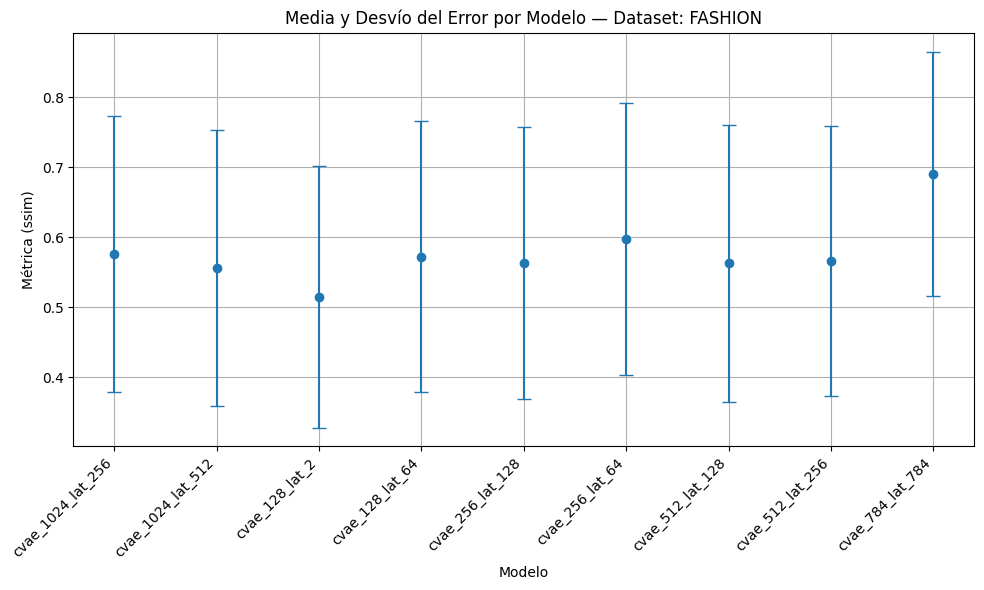

In [4]:
import numpy as np
import matplotlib.pyplot as plt

errores_np = np.array(errores)

means = errores_np.mean(axis=1).ravel()
stds  = errores_np.std(axis=1).ravel()

# Obtener nombres de modelos sin el sufijo del dataset
model_names = [m.name.replace(f"_{dataset}.keras", "") for m in models]

x = np.arange(len(means))

plt.figure(figsize=(10, 6))
plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Modelo — Dataset: {dataset.upper()}")
plt.xlabel("Modelo")
plt.ylabel(f"Métrica ({metric})")
plt.grid(True)


plt.xticks(x, model_names, rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"error_de_reconstruccion_modelos_{metric}_{dataset}.png")
plt.show()




## Error por clase

In [ ]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import load
from project.metrics.metrics import Metrics 
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
dataset = "mnist"

data = load.data(dataset=dataset)

model = load.cvae(lat=128,inter=512,dataset=dataset)

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
idx = 0
n_pictures = 1000
errores = []  # lista de filas, cada fila = un modelo


errores_modelo = []   # [(clase, error), ...]

for idx in range(n_pictures):
    x = x_test[idx : idx + 1]
    y = y_test[idx : idx + 1]

    # Codificar
    z_mean, _, z = model.encoder.predict([x, y], verbose=0)

    # Decodificar
    x_recon = model.decoder.predict([z, y], verbose=0)

    # Calcular clase y error
    clase = int(np.argmax(y))
    error_value = Metrics.ssim_grayscale(target=x, preds=x_recon)

    errores_modelo.append((clase, error_value))

errores.append(errores_modelo)



Usando mnist como dataset


### calculo

In [61]:
def estadisticas_por_clase(errores_modelo, num_clases=10):
    # errores_modelo = [(clase, error), ...]
    
    agrupados = {c: [] for c in range(num_clases)}
    for c, e in errores_modelo:
        agrupados[c].append(e)
    
    means = np.array([np.mean(agrupados[c]) for c in range(num_clases)])
    stds  = np.array([np.std(agrupados[c]) for c in range(num_clases)])
    return means, stds



### gráfico

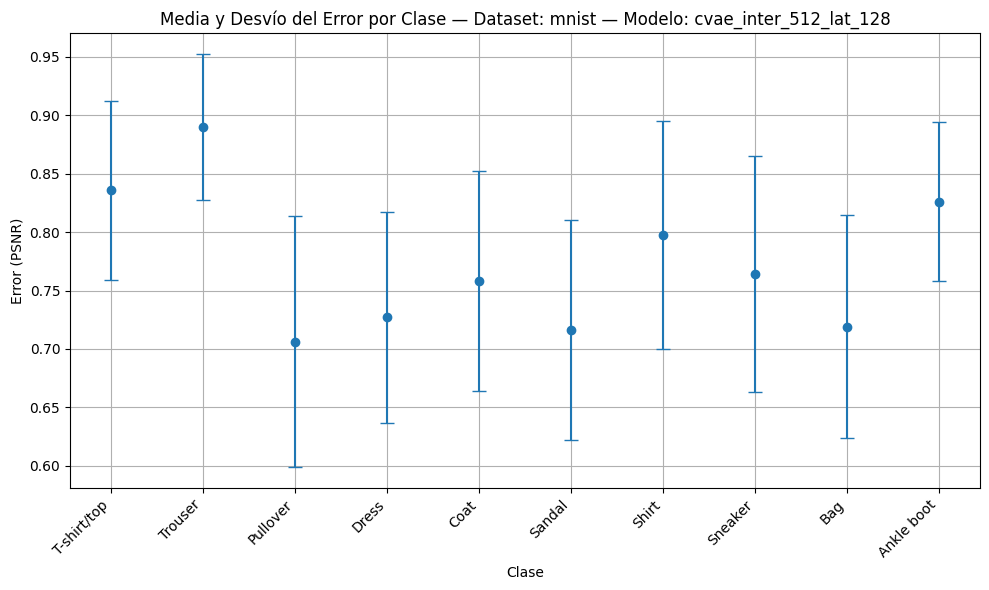

In [69]:
modelo_idx = 0   # elegí el modelo que quieras graficar
errores_modelo = errores[modelo_idx]

means, stds = estadisticas_por_clase(errores_modelo)

clases = np.arange(len(means))

#labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
lables = ["0","1","2","3","4","5","6","7","8","9"]

plt.figure(figsize=(10, 6))
plt.errorbar(clases, means, yerr=stds, fmt='o', capsize=5)

plt.title(f"Media y Desvío del Error por Clase — Dataset: {dataset} — Modelo: cvae_inter_512_lat_128")
plt.xlabel("Clase")
plt.ylabel("Error (PSNR)")
plt.grid(True)

plt.xticks(clases, labels, rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ssim_reconstruccion_por_clase_mnist_inter_512_lat_128")
plt.show()


Se usaron 1000 imagenes del dataset MNIST para evaluar el error de reconstrucción por dígito de cada modelo.
Se usan las imagenes originales y la reconstrución para calcular el error cuadratico medio entre ambas figuras.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from collections import defaultdict
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.metrics.metrics import Metrics 


def evaluar_reconstruccion_por_clase(cvae, x_test, y_test, metric="psnr"):
    """
    Evalúa la calidad de reconstrucción para cada clase.

    Args:
        cvae: modelo CVAE entrenado
        x_test: imágenes de prueba (shape: [N, 28, 28])
        y_test: etiquetas one-hot (shape: [N, 10])
        metric: 'mse' o 'bce'

    Returns:
        dict: promedio del error por clase
    """
    errores = defaultdict(list)

    for i in tqdm(range(len(x_test))):
        x = x_test[i : i + 1]  # (1, 28, 28)
        y = y_test[i : i + 1]  # (1, 10)

        # Codificar
        z_mean, _, z = cvae.encoder.predict([x, y], verbose=0)
        # Decodificar
        x_recon = cvae.decoder.predict([z, y], verbose=0)

        # Flatten para comparar
        x_flat = x.flatten()
        x_recon_flat = x_recon.flatten()
        if metric == "psnr":
            error = Metrics.psnr_grayscale(target=x_test, preds=x_recon)
        elif metric == "ssim":
            error = Metrics.ssim_grayscale(target=x_test, preds=x_recon)

        clase = np.argmax(y)
        errores[clase].append(error)

    # Promedio por clase
    resultados = {clase: np.mean(errores[clase]) for clase in errores}
    return  resultados

In [ ]:
from project.loader import load

dataset = "mnist" # cambiar aca

data = load.data(dataset=dataset)
models = load.all_models(dataset=dataset)

x_test = data["x_test"]
y_test = data["y_test"]

resultados = []
metric="psnr"
n_pictures=3
for m in models:
    resultados.append(evaluar_reconstruccion_por_clase(m, x_test[0:n_pictures], y_test[0:n_pictures], metric=metric))

for i in range(len(models)):
    print(f"{models[i].name}")
    for clase, error in sorted(resultados[i].items()):
        print(f" Dígito {clase}: error promedio = {error:.3f}")


Usando mnist como dataset
Encontrados 8 pares de modelos.


100%|██████████| 3/3 [00:00<00:00,  7.20it/s]

cvae_1024_lat_256_mnist.keras
 Dígito 1: error promedio = 14.111
 Dígito 2: error promedio = 12.041
 Dígito 7: error promedio = 12.724
cvae_1024_lat_512_mnist.keras
 Dígito 1: error promedio = 14.019
 Dígito 2: error promedio = 11.893
 Dígito 7: error promedio = 12.485
cvae_128_lat_2_mnist.keras
 Dígito 1: error promedio = 14.522
 Dígito 2: error promedio = 11.803
 Dígito 7: error promedio = 12.213
cvae_128_lat_64_mnist.keras
 Dígito 1: error promedio = 14.220
 Dígito 2: error promedio = 11.783
 Dígito 7: error promedio = 12.839
cvae_256_lat_128_mnist.keras
 Dígito 1: error promedio = 13.834
 Dígito 2: error promedio = 11.800
 Dígito 7: error promedio = 12.384
cvae_256_lat_64_mnist.keras
 Dígito 1: error promedio = 14.483
 Dígito 2: error promedio = 11.814
 Dígito 7: error promedio = 12.679
cvae_512_lat_128_mnist.keras
 Dígito 1: error promedio = 15.219
 Dígito 2: error promedio = 12.163
 Dígito 7: error promedio = 13.504
cvae_512_lat_256_mnist.keras
 Dígito 1: error promedio = 14.223


In [17]:
import matplotlib.pyplot as plt


def plot_error(resultados, ruta=None,title=""):
    valores = list(resultados.values())
    claves = list(resultados.keys())

    # Graficar barras
    bars = plt.bar(claves, valores)

    # Etiquetas encima de cada barra
    for i, bar in enumerate(bars):
        altura = bar.get_height()
        color_fondo = bar.get_facecolor()

        # Elegir blanco o negro según luminosidad del color de la barra
        r, g, b, _ = color_fondo
        color_texto = "black"

        plt.text(
            bar.get_x() + bar.get_width() / 2,  # centrado horizontal
            altura + 0.0015,  # un poco abajo del tope de la barra
            f"{valores[i]:.3f}",
            ha="center",
            va="top",
            color=color_texto,
            fontsize=10,
        )

    plt.xlabel("Dígito")
    plt.ylabel("Error de reconstrucción")
    plt.title(f"Reconstrucción promedio por clase modelo: {title}")
    plt.tight_layout()
    if ruta:
        plt.savefig(f"figs/{ruta}.png")
    plt.show()


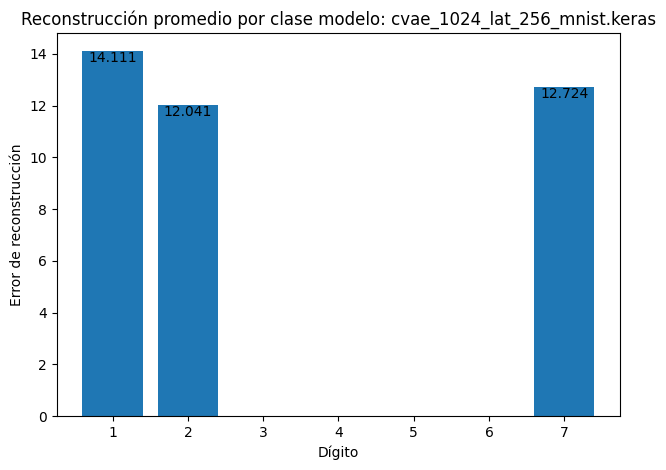

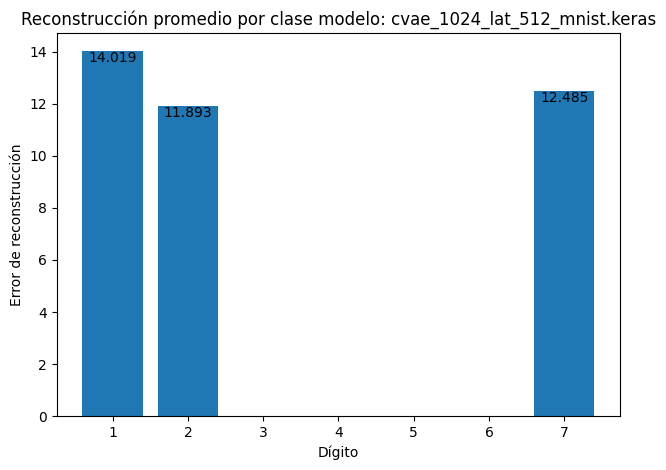

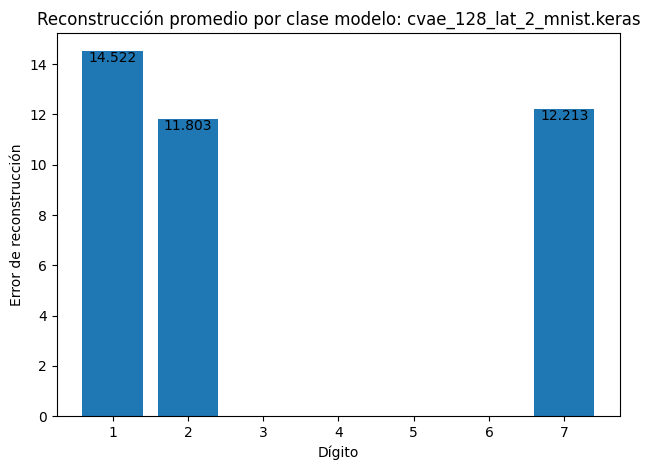

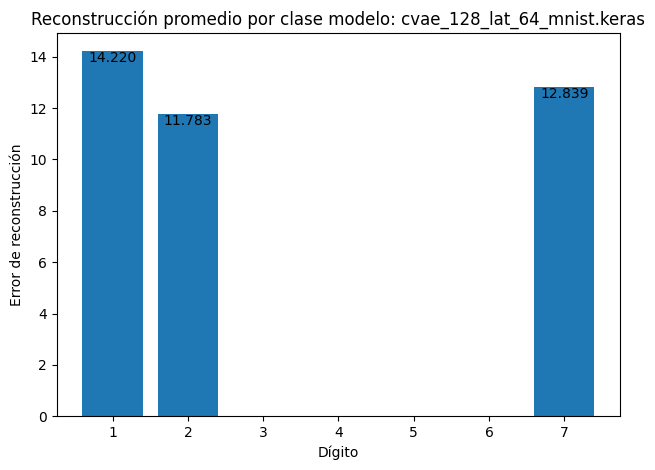

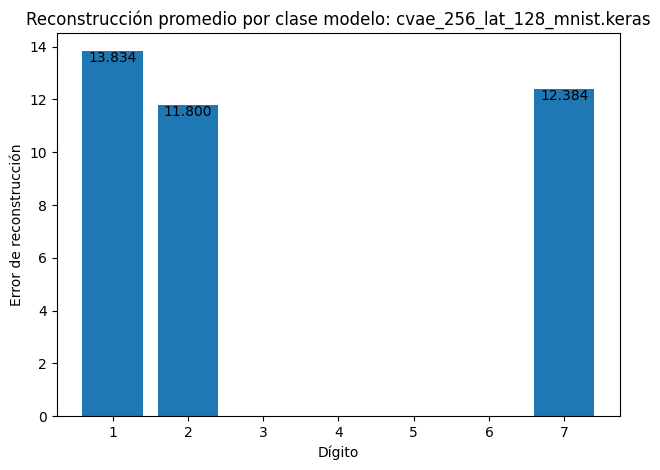

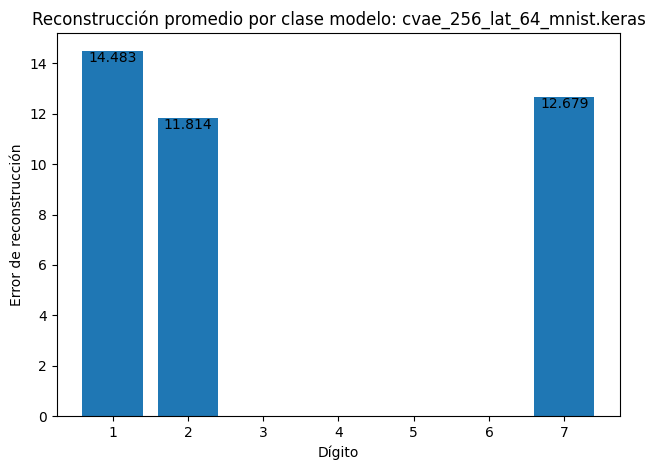

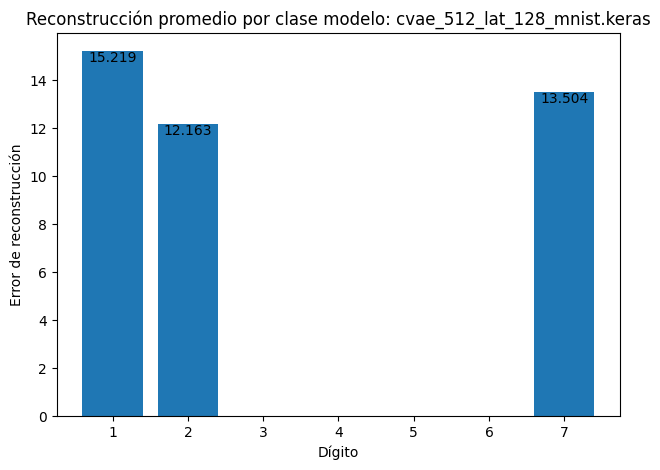

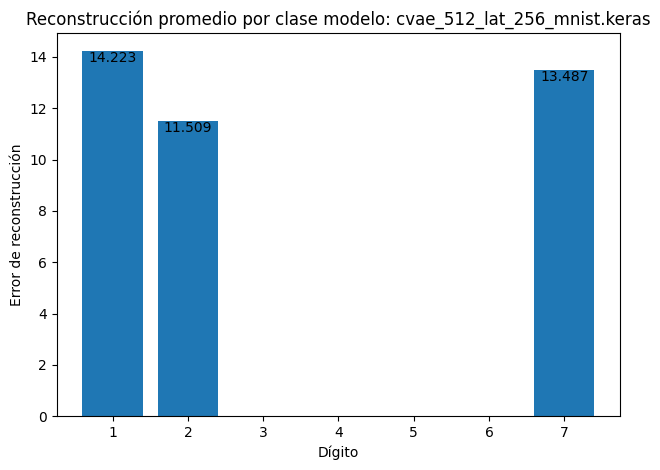

In [18]:
for m,r in zip(models,resultados):
#    plot_error(resultados=r, ruta=f"{m.name}_{metric}",title=m.name)
     plot_error(resultados=r, ruta=None,title=m.name)




quizas el error tiene que ver con la variabilidad de cada dígito ("mas formas de dibujar un 8 que mas formas de dibjuar un 1")
¿Como aprovehcar esto para mejorar el aprendizaje?
tal vez se pueda ponderar la loss de reconstruccion en funcion del dígito 
coeficinetes (al principio en 1)->una epoca-> validacion comparando contra estos valores-> ajuste-> epocas---> se "aplana"  este grafico 
el error.

Ambos modelos se comportan de maneras muy similiar, practicamente identicos. --> ¿Es necesario tener modelos tan grandes para esta tarea?

- El bajo error en la reconstrucción del dígito 1 ¿Tendra que ver con la poca "dispersión o variabilidad" para dibujar el número? --> El numero 2 y 8 son los que más error tienen, ¿Más formas de dibujar estos números?


Con el dataset de fashion-mnist. el error es mas parejo. La clase con menor error la clase de patalones, mientras que la que tiene más error de reconstrucción es la calse de bolsos. Todos los modelos tiene una distribución similar en cuanto en cuanto al error (En ambos datasets).  
No parece haber una mejora de la reconstrucción con más parametros.